# IEEE (MATPOWER) case — Dataset Overview

This notebook inspects a **Matpower `.m` case file**:

- file metadata (size, hash)
- Matpower scalars (`mpc.version`, `mpc.baseMVA`)
- core matrices (`bus`, `gen`, `branch`, `gencost`) as DataFrames
- quick consistency checks (IDs, endpoint integrity, connectivity)

---
#### Bootstrap

In [1]:
from _notebook_bootstrap import bootstrap

repo_root, datasets_root = bootstrap()
repo_root, datasets_root

(PosixPath('/home/user/workspace/datasets-utilities'),
 PosixPath('/home/user/data/datasets'))

---
#### Imports

In [2]:
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt

from dataloaders.matpower_case import MatpowerCase
from dataset_utils.plotting import bar_counts

pd.set_option("display.max_columns", 250)
pd.set_option("display.width", 140)

---
#### Load dataset object

In [3]:
# Select your file (can be changed to any other snapshot path under datasets_root)
relpath = "ieee_cases/pglib_opf_case300_ieee.m"

ds = MatpowerCase(datasets_root=datasets_root, relpath=relpath)
ds.path

PosixPath('/home/user/data/datasets/ieee_cases/pglib_opf_case300_ieee.m')

---
#### File overview
Key scalars + which Matpower blocks were detected.

In [4]:
ov = ds.overview()
ov

,key,value
0,path,/home/user/data/datasets/ieee_cases/pglib_o...
1,size_bytes,154407
2,sha256,7ecf056d5942135765200ad7ae8791c28f0d35fb1dc888...
3,mpc.version,2
4,mpc.baseMVA,100.0
5,blocks_present,"branch, bus, gen, gencost"
6,bus.rows,300
7,bus.cols,15
8,gen.rows,69
9,gen.cols,12


---
#### Load tables
Parse Matpower matrices into DataFrames.

In [5]:
tables = ds.load_tables()

shapes = (
    pd.DataFrame([{"table": k, "rows": int(v.shape[0]), "cols": int(v.shape[1])} for k, v in tables.items()])
    .sort_values("table")
    .reset_index(drop=True)
)
shapes

,table,rows,cols
0,branch,411,16
1,bus,300,15
2,gen,69,12
3,gencost,69,7


---
#### Core matrices preview

In [6]:
bus = tables.get("bus")
gen = tables.get("gen")
branch = tables.get("branch")
gencost = tables.get("gencost")

display(bus.head(10) if bus is not None else "missing: bus")
display(gen.head(10) if gen is not None else "missing: gen")
display(branch.head(10) if branch is not None else "missing: branch")
display(gencost.head(10) if gencost is not None else "missing: gencost")

,BUS_I,BUS_TYPE,PD,QD,GS,BS,BUS_AREA,VM,VA,BASE_KV,ZONE,VMAX,VMIN,bus_id,in_service
0,1,1,90.0,49.0,0.0,0.0,1,1,0,115.0,1,1.06,0.94,1,True
1,2,1,56.0,15.0,0.0,0.0,1,1,0,115.0,1,1.06,0.94,2,True
2,3,1,20.0,0.0,0.0,0.0,1,1,0,230.0,1,1.06,0.94,3,True
3,4,1,0.0,0.0,0.0,0.0,1,1,0,345.0,1,1.06,0.94,4,True
4,5,1,353.0,130.0,0.0,0.0,1,1,0,115.0,1,1.06,0.94,5,True
5,6,1,120.0,41.0,0.0,0.0,1,1,0,115.0,1,1.06,0.94,6,True
6,7,1,0.0,0.0,0.0,0.0,1,1,0,230.0,1,1.06,0.94,7,True
7,8,2,63.0,14.0,0.0,0.0,1,1,0,115.0,1,1.06,0.94,8,True
8,9,1,96.0,43.0,0.0,0.0,1,1,0,115.0,1,1.06,0.94,9,True
9,10,2,153.0,33.0,0.0,0.0,1,1,0,230.0,1,1.06,0.94,10,True


,GEN_BUS,PG,QG,QMAX,QMIN,VG,MBASE,GEN_STATUS,PMAX,PMIN,bus_id,in_service
0,8,0.0,0.0,10.0,-10.0,1,100,1,0,0,8,True
1,10,0.0,0.0,20.0,-20.0,1,100,1,0,0,10,True
2,20,0.0,0.0,20.0,-20.0,1,100,1,0,0,20,True
3,63,0.0,0.0,25.0,-25.0,1,100,1,0,0,63,True
4,76,0.0,23.5,35.0,12.0,1,100,1,0,0,76,True
5,84,724.0,0.0,240.0,-240.0,1,100,1,1448,0,84,True
6,91,92.5,41.0,93.0,-11.0,1,100,1,185,0,91,True
7,92,180.0,0.0,153.0,-153.0,1,100,1,360,0,92,True
8,98,46.5,8.5,47.0,-30.0,1,100,1,93,0,98,True
9,108,98.5,26.5,77.0,-24.0,1,100,1,197,0,108,True


,F_BUS,T_BUS,BR_R,BR_X,BR_B,RATE_A,RATE_B,RATE_C,TAP,SHIFT,BR_STATUS,ANGMIN,ANGMAX,from_bus,to_bus,in_service
0,37,9001,0.00006,0.00046,0.0,9900,63230,63230,1.0082,0.0,1,-30,30,37,9001,True
1,9001,9005,0.0008,0.00348,0.0,8215,8215,8215,0.0,0.0,1,-30,30,9001,9005,True
2,9001,9006,0.02439,0.43682,0.0,68,68,68,0.9668,0.0,1,-30,30,9001,9006,True
3,9001,9012,0.03624,0.64898,0.0,46,46,46,0.9796,0.0,1,-30,30,9001,9012,True
4,9005,9051,0.01578,0.37486,0.0,79,79,79,1.0435,0.0,1,-30,30,9005,9051,True
5,9005,9052,0.01578,0.37486,0.0,79,79,79,0.9391,0.0,1,-30,30,9005,9052,True
6,9005,9053,0.01602,0.38046,0.0,78,78,78,1.0435,0.0,1,-30,30,9005,9053,True
7,9005,9054,0.0,0.152,0.0,193,193,193,1.0435,0.0,1,-30,30,9005,9054,True
8,9005,9055,0.0,0.8,0.0,37,37,37,1.0435,0.0,1,-30,30,9005,9055,True
9,9006,9007,0.05558,0.24666,0.0,117,117,117,0.0,0.0,1,-30,30,9006,9007,True


,MODEL,STARTUP,SHUTDOWN,NCOST,COST_1,COST_2,COST_3
0,2,0,0,3,0,0.0,0
1,2,0,0,3,0,0.0,0
2,2,0,0,3,0,0.0,0
3,2,0,0,3,0,0.0,0
4,2,0,0,3,0,0.0,0
5,2,0,0,3,0,22.409835,0
6,2,0,0,3,0,46.100054,0
7,2,0,0,3,0,54.164939,0
8,2,0,0,3,0,27.238416,0
9,2,0,0,3,0,38.430722,0


---
#### Basic counts

In [7]:
counts = ds.basic_counts()
counts

{'buses_total': 300,
 'gens_total': 69,
 'branches_total': 411,
 'gencost_total': 69}

---
#### Plot: element counts

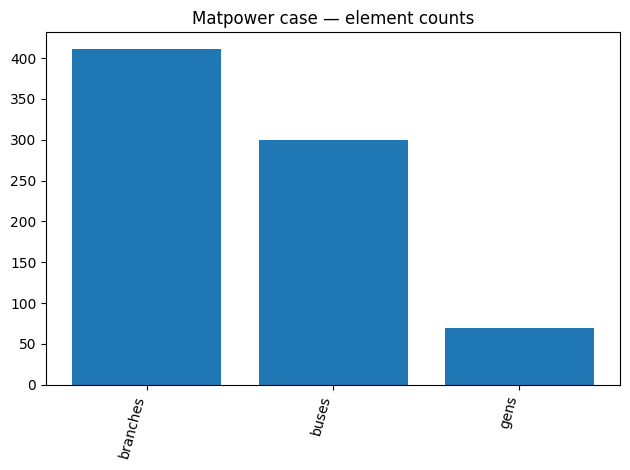

In [8]:
bar_counts(ds.counts_for_plot(), "Matpower case — element counts", top_n=10)

---
#### Basic quality checks
- missing/duplicate bus IDs
- null rates on key columns

In [9]:
checks = ds.duplicate_and_empty_checks()
checks


{'bus_id_null': 0,
 'bus_id_duplicates': 0,
 'branch_null_pct': {'from_bus': 0.0,
  'to_bus': 0.0,
  'BR_R': 0.0,
  'BR_X': 0.0,
  'BR_STATUS': 0.0},
 'gen_null_pct': {'bus_id': 0.0, 'PG': 0.0, 'QG': 0.0, 'GEN_STATUS': 0.0}}

---
#### Endpoint integrity
- branches reference existing buses
- generators reference existing buses

In [10]:
integrity = ds.endpoint_integrity()
integrity

{'branch_bad_from_bus_count': 0,
 'branch_bad_to_bus_count': 0,
 'branch_bad_from_bus_sample': [],
 'branch_bad_to_bus_sample': [],
 'gen_bad_bus_count': 0,
 'gen_bad_bus_sample': []}

---
#### Connectivity (union-find)
Connectivity on the bus graph using in-service branches (if `BR_STATUS` exists).

In [11]:
conn = ds.connectivity_stats(include_only_in_service=True)
pd.Series(conn, name="connectivity")

nodes                       300
edges                       411
connected_components          1
largest_component_size      300
top_component_sizes       [300]
isolated_buses_count          0
isolated_buses_sample        []
edges_only_in_service      True
Name: connectivity, dtype: object

---
#### Connectivity graph (networkx sanity view)
Undirected connectivity view for small-case visual inspection.

In [12]:
if bus is not None and branch is not None and "bus_id" in bus.columns:
    nodes = bus["bus_id"].dropna().astype(int).tolist()

    br = branch
    if "in_service" in br.columns:
        br = br[br["in_service"].fillna(False)]

    edges = []
    if "from_bus" in br.columns and "to_bus" in br.columns:
        edges = list(zip(br["from_bus"].dropna().astype(int), br["to_bus"].dropna().astype(int)))

    G = nx.Graph()
    G.add_nodes_from(nodes)
    G.add_edges_from(edges)

    isolated = sorted([n for n, d in G.degree() if d == 0])

    {
        "nodes": G.number_of_nodes(),
        "edges": G.number_of_edges(),
        "connected_components": nx.number_connected_components(G) if G.number_of_nodes() else 0,
        "isolated_buses_count": len(isolated),
        "isolated_buses_sample": isolated[:20],
    }

---
#### Topology sketch
Spring layout; useful only for small cases.

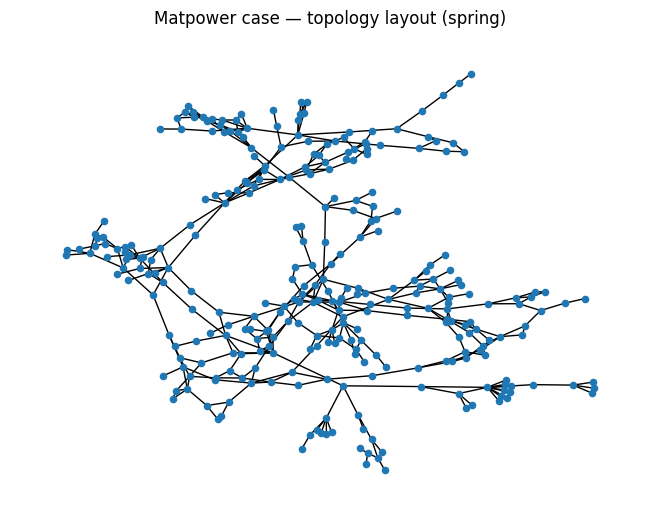

In [ ]:
if "G" in globals() and G.number_of_nodes() and G.number_of_edges() and G.number_of_nodes() <= 300:
    plt.figure()
    pos = nx.spring_layout(G, seed=1)
    nx.draw(G, pos=pos, node_size=20, with_labels=False)
    plt.title("IEEE case — topology layout")
    plt.show()

---
#### Export ML-ready artifacts (optional)
Writes nodes/edges/tables + metadata + manifest under `data/processed/`.

In [14]:
out = ds.export_ml_ready(
    format="parquet",
    force=True,
    include_only_in_service=False,
    manifest_version="v1",
)
out

{'output_dir': '/home/user/workspace/datasets-utilities/data/processed/matpower_case/default/v1',
 'artifacts': {'nodes': 'nodes.parquet',
  'edges': 'edges.parquet',
  'tables': {'branch': 'tables/branch.parquet',
   'bus': 'tables/bus.parquet',
   'gen': 'tables/gen.parquet',
   'gencost': 'tables/gencost.parquet'},
  'metadata': 'metadata.json',
  'manifest': 'manifest.json'},
 'counts': {'source': {'bus': 300, 'branch': 411, 'gen': 69, 'gencost': 69},
  'export': {'nodes': 300,
   'edges': 411,
   'tables': {'bus': 300, 'gen': 69, 'gencost': 69, 'branch': 411}}},
 'metadata': {'dataset': 'matpower_case',
  'source_format': 'matpower',
  'input_path': '/home/user/data/datasets/ieee_cases/pglib_opf_case300_ieee.m',
  'file_sha256': '7ecf056d5942135765200ad7ae8791c28f0d35fb1dc888ba2c32dfc950f3c2f5',
  'mpc.version': '2',
  'mpc.baseMVA': 100.0,
  'counts': {'bus': 300, 'branch': 411, 'gen': 69, 'gencost': 69}},
 'schema_hash': 'c147a594f24f1c2d7eb9b0748922f5f910aafe9d4e921c592a5f3fa67